**Project intro:**
FAERS (FDA Adverse Event Reporting System) is a U.S. Food and Drug Administration (FDA) database containing voluntary reports of adverse events, medication errors, and product quality complaints for human drugs and biologics, allowing for post-marketing safety surveillance. 

The goal of my analysis is to analyze this publicly listed FAERS data from Quarter 4 of 2025 as a way to practice my coding proficiency with SQL queries and PANDAS while taking note of interesting trends that I discover. In total, there are seven tables and 385k case reports within this one quarter of post-market drug surveillance data. 

There are several key limitations that are important to note. First off, this data contains a combination of voluntary and mandatory reports. Those voluntarily reported (patient or provider)are not representative of ALL adverse events secondary to drug and biologics usage during this quarter. Additionally, there are no denominators, meaning that while this data contains the amount of people reporting adverse events for a specific drug (say 500), there is no mention of how many people in total were using that drug (could be 50, 50,000, or 50,000,000) which means it can be difficult to draw accurate conclusions. There can also be duplicate reports further skewing the data. One adverse reaction can be reported by the patient, their doctor, and the drug manufacturer. 

*5 most interesting findings:*
1. Death vs hospitalization have distinct drug profiles
2. Off-label use dominates serious outcome reaction terms across both categories
3. Physician-reported deaths tell a cleaner, oncology-specific story vs raw data
4. Elderly patients are 2x overrepresented in death vs their share of overall reports
5. Men die at higher rates despite women reporting more overall

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect(r'C:\Users\Owner\Desktop\AI_Learning_2025\Projects\portfolio-proj-3\faers_q4_2025.db')

In [5]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,DEMO25Q4
1,DRUG25Q4
2,INDI25Q4
3,OUTC25Q4
4,REAC25Q4
5,RPSR25Q4
6,THER25Q4


In [6]:
pd.read_sql("SELECT * FROM OUTC25Q4 LIMIT 10", conn)

# DE - death
# OT - other serious 
# HO - hospitalizations
# LT - life threatening
# DS - disability

,primaryid,caseid,outc_cod
0,100324053,10032405,DE
1,100324053,10032405,OT
2,1012809821,10128098,OT
3,101406268,10140626,HO
4,101406268,10140626,OT
5,101515934,10151593,HO
6,1016133068,10161330,OT
7,102069944,10206994,DE
8,102069944,10206994,OT
9,102776502,10277650,HO


In [7]:
pd.read_sql("""SELECT outc_cod, COUNT(*) AS tot_outc 
            FROM OUTC25Q4
            GROUP BY outc_cod
            ORDER BY tot_outc DESC;""", conn)

,outc_cod,tot_outc
0,OT,161458
1,HO,80556
2,DE,26291
3,LT,13126
4,DS,6065
5,CA,1371
6,RI,854


In [8]:
# when only filtering by "DE" column AKA just top drugs associated with death, no other filters

pd.read_sql("""SELECT DRUG25Q4.drugname, COUNT(DISTINCT DRUG25Q4.primaryid) AS outc_drugs
            FROM DRUG25Q4
            JOIN OUTC25Q4 ON DRUG25Q4.primaryid = OUTC25Q4.primaryid
            WHERE OUTC25Q4.outc_cod = 'DE'
            GROUP BY DRUG25Q4.drugname
            ORDER BY outc_drugs DESC
            LIMIT 20;""", conn)

# And when you look at the pattern — prednisone, methotrexate, mycophenolate, folic acid, leflunomide, Cosentyx, Humira, Enbrel, Actemra, Infliximab — what do you notice? 
# Almost this entire top 20 is immunosuppressants and biologics used in autoimmune disease. 

,drugname,outc_drugs
0,PREDNISONE,1552
1,ACETAMINOPHEN,1520
2,RITUXIMAB,1498
3,METHOTREXATE,1109
4,MYCOPHENOLATE MOFETIL,1055
5,FOLIC ACID,946
6,DEXAMETHASONE,824
7,COSENTYX,783
8,OXYCODONE,766
9,ERELZI,760


In [9]:
pd.read_sql("SELECT DISTINCT role_cod FROM DRUG25Q4", conn)

# PS — Primary Suspect (reporter believes this drug caused the event)
# SS — Secondary Suspect
# C — Concomitant (patient was taking it, not suspected)
# I — Interacting (suspected drug-drug interaction)
# DN — Drug Not Administered

,role_cod
0,PS
1,SS
2,C
3,I
4,DN


In [10]:
pd.read_sql("""SELECT DRUG25Q4.drugname, COUNT(DISTINCT DRUG25Q4.primaryid) AS outc_drugs
            FROM DRUG25Q4
            JOIN OUTC25Q4 ON DRUG25Q4.primaryid = OUTC25Q4.primaryid
            WHERE OUTC25Q4.outc_cod = 'DE' AND role_cod = 'PS'
            GROUP BY DRUG25Q4.drugname
            ORDER BY outc_drugs DESC
            LIMIT 20;""", conn)

# the drugs being flagged as primary suspects in death cases are predominantly last-line or serious-disease treatments.


,drugname,outc_drugs
0,DAPAGLIFLOZIN,611
1,NUPLAZID,492
2,KEYTRUDA,431
3,RITUXIMAB,311
4,OSIMERTINIB,294
5,DURVALUMAB,291
6,CARBIDOPA\LEVODOPA,281
7,ENHERTU,266
8,BUDESONIDE\FORMOTEROL\GLYCOPYRRONIUM,259
9,VENCLEXTA,252


In [11]:
pd.read_sql("""SELECT REAC25Q4.pt, COUNT(DISTINCT REAC25Q4.primaryid) AS total_cases
            FROM REAC25Q4   
            JOIN OUTC25Q4 ON REAC25Q4.primaryid = OUTC25Q4.primaryid
            JOIN DRUG25Q4 ON REAC25Q4.primaryid = DRUG25Q4.primaryid
            WHERE OUTC25Q4.outc_cod = 'DE' AND role_cod = 'PS'
            GROUP BY REAC25Q4.pt
            ORDER BY total_cases DESC
            LIMIT 20;""", conn)

# seriously ill patients, many with cancer, on immunosuppressive therapies, dying from infections, disease progression, and treatment failure 
# — with a notable off-label use signal worth investigating further.


,pt,total_cases
0,Death,13024
1,Off label use,1937
2,Pneumonia,1214
3,Drug ineffective,1169
4,General physical health deterioration,859
5,Diarrhoea,849
6,Pyrexia,787
7,Condition aggravated,786
8,Dyspnoea,772
9,Toxicity to various agents,748


Primary suspect drugs in death cases are dominated by oncology and serious disease treatments
The reaction profile shows infections, disease progression, and a notable off-label use signal

In [12]:
pd.read_sql("""SELECT DRUG25Q4.drugname, COUNT(DISTINCT DRUG25Q4.primaryid) AS total_cases
            FROM DRUG25Q4
            JOIN OUTC25Q4 ON DRUG25Q4.primaryid = OUTC25Q4.primaryid
            WHERE OUTC25Q4.outc_cod = 'HO' AND DRUG25Q4.role_cod = 'PS'
            GROUP BY DRUG25Q4.drugname
            ORDER BY total_cases DESC
            LIMIT 20;""", conn)

,drugname,total_cases
0,SKYRIZI,1715
1,DUPIXENT,1539
2,RINVOQ,1368
3,VEDOLIZUMAB,1242
4,ACETAMINOPHEN,1127
5,MOUNJARO,805
6,KEYTRUDA,765
7,LENALIDOMIDE,714
8,HUMAN IMMUNOGLOBULIN G,703
9,OZEMPIC,701


**Finding 1**

*For context, PS = Primary Suspect. This means that this drug was determined to be the most likely to have caused this adverse reaction within the consumer.*


The leading PS-filtered deaths were dominated by oncology drugs — Keytruda, Durvalumab, Enhertu. PS-filtered hospitalizations are dominated by immunology and metabolic disease — Skyrizi, Dupixent, Rinvoq, Vedolizumab, Ozempic, Mounjaro, Metformin.
Skyrizi and Dupixent at the top is interesting because those are relatively newer biologics with massive commercial uptake — psoriasis, atopic dermatitis, IBD. High prescription volume means more reports even if the per-patient risk is low. That's the denominator problem again - there is no denominator, so there's no way to make a comment regarding how often this occurs in patients who take these drugs because we have no idea how many patients are taking them. 
Mounjaro and Ozempic showing up is noteworthy. GLP-1s are the highest prescribed drug class in the country right now, so seeing them in hospitalization reports as primary suspects is exactly the kind of signal FDA is actively monitoring — pancreatitis, gastroparesis, bowel obstruction are known GLP-1 concerns that can land people in the hospital. 

Death and hospitalizations have fundamentally different drug profiles. 

In [13]:
pd.read_sql("""SELECT REAC25Q4.pt, COUNT(DISTINCT REAC25Q4.primaryid) AS total_cases
            FROM REAC25Q4   
            JOIN OUTC25Q4 ON REAC25Q4.primaryid = OUTC25Q4.primaryid
            JOIN DRUG25Q4 ON REAC25Q4.primaryid = DRUG25Q4.primaryid
            WHERE OUTC25Q4.outc_cod = 'HO' AND role_cod = 'PS'
            GROUP BY REAC25Q4.pt
            ORDER BY total_cases DESC
            LIMIT 20;""", conn)


,pt,total_cases
0,Off label use,6310
1,Diarrhoea,4768
2,Pneumonia,4476
3,Nausea,4399
4,Vomiting,4212
5,Dyspnoea,3996
6,Fatigue,3946
7,Drug ineffective,3935
8,Pyrexia,3605
9,Fall,3582


**Finding 2**

Death cases are dominated by oncology drugs, yet these statistics aren't evidence that these drugs are high contributors to mortality. Many of these fatal outcomes were the result of infection and disease progression reactions due to compromised immune systems in aging or already sick patients. Without medical intervention, these patients would still be destined for a fatal outcome, so their complex medication regimens are merely postponing their eventual mortality. 

Hospitalization cases from mainstream chronic disease drugs are much more interesting, especially due to the extremely high rate of off-label use. Off-label use appearing as top reaction term in BOTH outcome categories is an interesting find because it suggests that regardless of death or hospitalization, using off-label medications in a medical scope outside of their clinical testing increases patient risk. 

Off-label means prescribing an FDA-approved drug for a use that the FDA hasn't specifically approved — different indication, different patient population, different dose, or different route than what's on the label.
The drug itself is legal and approved. The specific use just hasn't gone through the formal FDA approval process for that particular application.

Common examples include Ozempic, which is FDA approved for Type 2 diabetes but widely used purely for weight loss in non-diabetic patients. Similarly, Gabapentin is approved for epilepsy and nerve pain but it routinely gets prescribed off-label for anxiety, insomnia, and alcohol withdrawal.
This extends to oncology as well, where chemotherapy drugs are frequently used off-label for cancer types outside their approved indications, as oncologists extrapolate from similar tumor biology.

Off-label use isn't inherently dangerous or illegal — it's actually extremely common and sometimes the standard of care. But it means the drug was used in a population or context where the safety data is thinner. FDA approval requires clinical trials proving safety and efficacy for a specific use. Off-label skips that bar.
So when off-label use keeps appearing as a top term in serious outcome reports, it raises the question: are patients being harmed in contexts where we don't have robust safety data?

In [14]:
pd.read_sql("""SELECT DRUG25Q4.drugname, COUNT(DISTINCT REAC25Q4.primaryid) AS total_cases
            FROM DRUG25Q4 
            JOIN REAC25Q4 ON DRUG25Q4.primaryid = REAC25Q4.primaryid
            WHERE REAC25Q4.pt = 'Off label use'
            GROUP BY DRUG25Q4.drugname
            ORDER BY total_cases DESC
            LIMIT 20;""", conn)
            

,drugname,total_cases
0,PREDNISONE,2642
1,RITUXIMAB,1857
2,ACETAMINOPHEN,1711
3,INFLIXIMAB,1589
4,METHOTREXATE,1448
5,VEDOLIZUMAB,1346
6,MYCOPHENOLATE MOFETIL,1104
7,DUPIXENT,1076
8,METHYLPREDNISOLONE,1066
9,FOLIC ACID,975


In [15]:
pd.read_sql("""SELECT DRUG25Q4.drugname, COUNT(DISTINCT REAC25Q4.primaryid) AS total_cases
            FROM DRUG25Q4 
            JOIN REAC25Q4 ON DRUG25Q4.primaryid = REAC25Q4.primaryid
            WHERE REAC25Q4.pt = 'Off label use' AND DRUG25Q4.role_cod = 'PS'
            GROUP BY DRUG25Q4.drugname
            ORDER BY total_cases DESC
            LIMIT 20;""", conn)

#The broader pattern — the off-label primary suspect list is dominated by specialty biologics with narrow indications being used in adjacent conditions. 
# That's a structural feature of modern pharmacology. Biologic mechanisms are often applicable across multiple disease states but FDA approval is indication-specific and expensive to obtain. 
# Physicians extrapolate. FAERS captures the consequences.

,drugname,total_cases
0,VEDOLIZUMAB,1302
1,INFLIXIMAB,1042
2,DUPIXENT,1037
3,RITUXIMAB,757
4,LANTUS SOLOSTAR,751
5,BIMZELX,560
6,JAKAFI,492
7,BEVACIZUMAB,393
8,MYCOPHENOLATE MOFETIL,344
9,MOUNJARO,318


In [16]:
pd.read_sql("SELECT * FROM DEMO25Q4 LIMIT 1", conn).columns.tolist()

['primaryid',
 'caseid',
 'caseversion',
 'i_f_code',
 'event_dt',
 'mfr_dt',
 'init_fda_dt',
 'fda_dt',
 'rept_cod',
 'auth_num',
 'mfr_num',
 'mfr_sndr',
 'lit_ref',
 'age',
 'age_cod',
 'age_grp',
 'sex',
 'e_sub',
 'wt',
 'wt_cod',
 'rept_dt',
 'to_mfr',
 'occp_cod',
 'reporter_country',
 'occr_country']

In [17]:
pd.read_sql("""SELECT DEMO25Q4.sex, COUNT(DEMO25Q4.primaryid) AS sex_count
            FROM DEMO25Q4  
            GROUP BY DEMO25Q4.sex 
            ORDER BY sex_count DESC
            LIMIT 20;""", conn)


,sex,sex_count
0,F,184311
1,M,121907
2,NaN,79070


**Finding 3**

When counting the demographics represented within this data analysis, it should come as no surprise that women make up nearly 60% of the known population while men comprise about 40%. This is actually a well-documented trend in healthcare in general, as women interact with the healthcare system more often than men. 

Why is this? Well, the simple reason is that women are more likely to actually present for clinical evaluation when experiencing symptoms as men. This isn't necessarily because men 'tough it out' and is an interesting social phenomenon, which is reflected appropriately in the FAERS data demographics. 

In [18]:
pd.read_sql("""SELECT DEMO25Q4.sex, COUNT(DISTINCT DEMO25Q4.primaryid) AS sex_count
            FROM DEMO25Q4  
            JOIN OUTC25Q4 ON DEMO25Q4.primaryid = OUTC25Q4.primaryid
            WHERE OUTC25Q4.outc_cod = 'DE'
            GROUP BY DEMO25Q4.sex 
            ORDER BY sex_count DESC
            LIMIT 20;""", conn)

# Men have a higher rate of appearing in death cases despite women reporting adverse events more frequently overall

,sex,sex_count
0,M,11867
1,F,10214
2,NaN,4210


In [19]:
pd.read_sql("""SELECT age, age_cod, age_grp 
            FROM DEMO25Q4 
            WHERE age IS NOT NULL 
            LIMIT 20""", conn)

# Good news: age_cod is mostly YR meaning years, so the values are interpretable directly.
# Bad news: age_grp has a lot of NaN and the raw age field is a continuous number, so we can't just GROUP BY age — you'd get one row per age value which is useless.
# We need to bucket ages into meaningful clinical groups. The standard breakdown is:

# 0-17 Pediatric
# 18-44 Young adult
# 45-64 Middle aged
# 65+ Elderly

,age,age_cod,age_grp
0,7,YR,NaN
1,19,YR,A
2,30,YR,A
3,61,YR,A
4,66,YR,E
5,31,YR,NaN
6,63,YR,A
7,49,YR,NaN
8,37,YR,NaN
9,38,YR,NaN


In [20]:
pd.read_sql("""SELECT 
    CASE 
        WHEN age < 18 THEN 'Pediatric'
        WHEN age < 45 THEN 'Young Adult'
        WHEN age < 65 THEN 'Middle Aged'
        ELSE 'Elderly'
    END AS age_group,
    COUNT(DISTINCT primaryid) AS total_cases
FROM DEMO25Q4
WHERE age IS NOT NULL AND age_cod = 'YR'
GROUP BY age_group
ORDER BY total_cases DESC""", conn)

,age_group,total_cases
0,Elderly,92135
1,Middle Aged,76029
2,Young Adult,53970
3,Pediatric,10095


In [21]:
pd.read_sql("""SELECT 
    CASE 
        WHEN age < 18 THEN 'Pediatric'
        WHEN age < 45 THEN 'Young Adult'
        WHEN age < 65 THEN 'Middle Aged'
        ELSE 'Elderly'
    END AS age_group,
    COUNT(DISTINCT DEMO25Q4.primaryid) AS total_cases
FROM DEMO25Q4
JOIN OUTC25Q4 ON DEMO25Q4.primaryid = OUTC25Q4.primaryid
WHERE age IS NOT NULL AND age_cod = 'YR' AND OUTC25Q4.outc_cod = 'DE'
GROUP BY age_group
ORDER BY total_cases DESC""", conn)

# The clinical interpretation — elderly patients are overrepresented in death outcomes beyond what their reporting frequency alone would predict.
# That's consistent with everything we know about polypharmacy, reduced renal and hepatic clearance affecting drug metabolism, and reduced physiologic reserve in older patients. 
# An adverse event that a 35 year old weathers becomes fatal in a 75 year old.

,age_group,total_cases
0,Elderly,9524
1,Middle Aged,4196
2,Young Adult,2637
3,Pediatric,295


*Finding #4*

Elderly patients are overrepresented by the data, appearing over twice as often as middle aged age group. This data was filtered by 'age groups' using conditionals that allow for each age group to be separated into distinct categories before applying the outcome = DE filter to an age group within age_cod. This result is actually completely expected, albeit perhaps not quite in these stark quantities.

Elderly patients are much more likely to be on polypharmacy medication regimens in order to treat medical conditions that are gradually escalating in severity and progression as their immune systems become weaker with age. In general, as people mature and become older, the natural wear and tear on their body results in medical ailments which corresponds to medical management. It is common knowledge that a common URI in a teenager can likely be resolved with a few days of rest and some cough medication, whereas the same exact infection in elderly patients can become a fatal complication. This is the same reasoning as to why falling episodes often lead to severe deterioration in an elderly patients' health, but the pediatric and young adult age group rarely experience similar consequences.


In [22]:
pd.read_sql("""SELECT occp_cod, COUNT(DISTINCT primaryid) AS total_cases
FROM DEMO25Q4
GROUP BY occp_cod
ORDER BY total_cases DESC""", conn)

# CN — Consumer (patient/family member) — 129,658
# HP — Health Professional — 82,287
# MD — Physician — 75,639
# PH — Pharmacist — 18,112
# LW — Lawyer — 2,474
# NaN — Unknown — 77,118

,occp_cod,total_cases
0,CN,129658
1,HP,82287
2,NaN,77118
3,MD,75639
4,PH,18112
5,LW,2474


In [23]:
#  filtering the data by outcome = death, role in outcome = primary suspect, and occupation that reported the result = doctor

pd.read_sql("""SELECT DRUG25Q4.drugname, COUNT(DISTINCT DRUG25Q4.primaryid) AS total_cases
FROM DRUG25Q4
JOIN OUTC25Q4 ON DRUG25Q4.primaryid = OUTC25Q4.primaryid
JOIN DEMO25Q4 ON DRUG25Q4.primaryid = DEMO25Q4.primaryid
WHERE outc_cod = 'DE' AND role_cod = 'PS' AND occp_cod = 'MD'
GROUP BY drugname
ORDER BY total_cases DESC
LIMIT 20""", conn)

,drugname,total_cases
0,KEYTRUDA,223
1,YERVOY,202
2,DAPAGLIFLOZIN,111
3,GLIVEC,89
4,TECENTRIQ,85
5,IMFINZI,84
6,PEMBROLIZUMAB,78
7,VENETOCLAX,73
8,CARBOPLATIN,73
9,BUPROPION HYDROCHLORIDE,73


Same question — "which drugs are associated with death?" — two completely different answers depending on how you filter the data. That's not a data quirk, that's a fundamental lesson in pharmacovigilance methodology.
The unfiltered list reflects who takes what — autoimmune patients on complex polypharmacy regimens are the highest volume reporters, so their drugs dominate.
The physician-filtered PS list reflects clinical judgment about causality — doctors specifically attributing death to a drug. And that story is almost exclusively checkpoint inhibitor oncology.

**Finding 5**

Rather than analyzing the clinical implications, the important distinction here is actually in the data filtration methods. Earlier in the analysis, I had filtered the drugs specifically by outcome ('DE' = death) yet the drugs listed were entirely different than this newest filter, where the drugs are filtered by a combination of outcome (DE), role in outcome (PS), and who actually reported this to the FDA (MD). 

In the previous filter, drugs like Prednisone (1552), Acetaminophen (1520), and Rituximab (1498) were at the top of the list due to the volume of these drugs prescribed, but this doesn't actually correspond to having a higher mortality risk. When using the tri-fold filtering approach that accounts for outcome, reaction, and reporter, the entire drug list changes dramatically and the overall volume is significantly reduced. This helps to clear up some of the 'noise' that was inflating the portrayed risk of drugs when filtered by outcome = DE alone. 

The new list contains Keytruda (223), Yervoy (202), and Dapagliflozin (111) as the top three. While the overall volume of these filtered results is much lower, this should be expected since the requirements to appear on this list are much more stringent. The 223 total cases where Keytruda is counted is much more significant in assessing risk levels because in each of these cases, Keytruda is the primary suspect for the outcome being death as reported by the physician. This is no longer a generic patient report based on an anecdotal or personal experience, but is instead a physician reporting their suspicion of Keytruda likely being the main contributor for a patient's fatal outcome.

In [24]:
pd.read_sql("SELECT * FROM RPSR25Q4 LIMIT 5", conn)

,primaryid,caseid,rpsr_cod
0,258691631,25869163,HP
1,258692071,25869207,HP
2,258692081,25869208,HP
3,258692351,25869235,HP
4,258692761,25869276,HP


In [27]:
pd.read_sql("""SELECT rpsr_cod, COUNT(DISTINCT primaryid) AS total_cases
FROM RPSR25Q4
GROUP BY rpsr_cod
ORDER BY total_cases DESC""", conn)

,rpsr_cod,total_cases
0,CSM,7094
1,HP,3517
2,FGN,83


In [28]:
# Matplot start

death_drugs = pd.read_sql("""
    SELECT DRUG25Q4.drugname, COUNT(DISTINCT DRUG25Q4.primaryid) AS total_cases
    FROM DRUG25Q4
    JOIN OUTC25Q4 ON DRUG25Q4.primaryid = OUTC25Q4.primaryid
    WHERE OUTC25Q4.outc_cod = 'DE' AND DRUG25Q4.role_cod = 'PS'
    GROUP BY DRUG25Q4.drugname
    ORDER BY total_cases DESC
    LIMIT 15
""", conn)

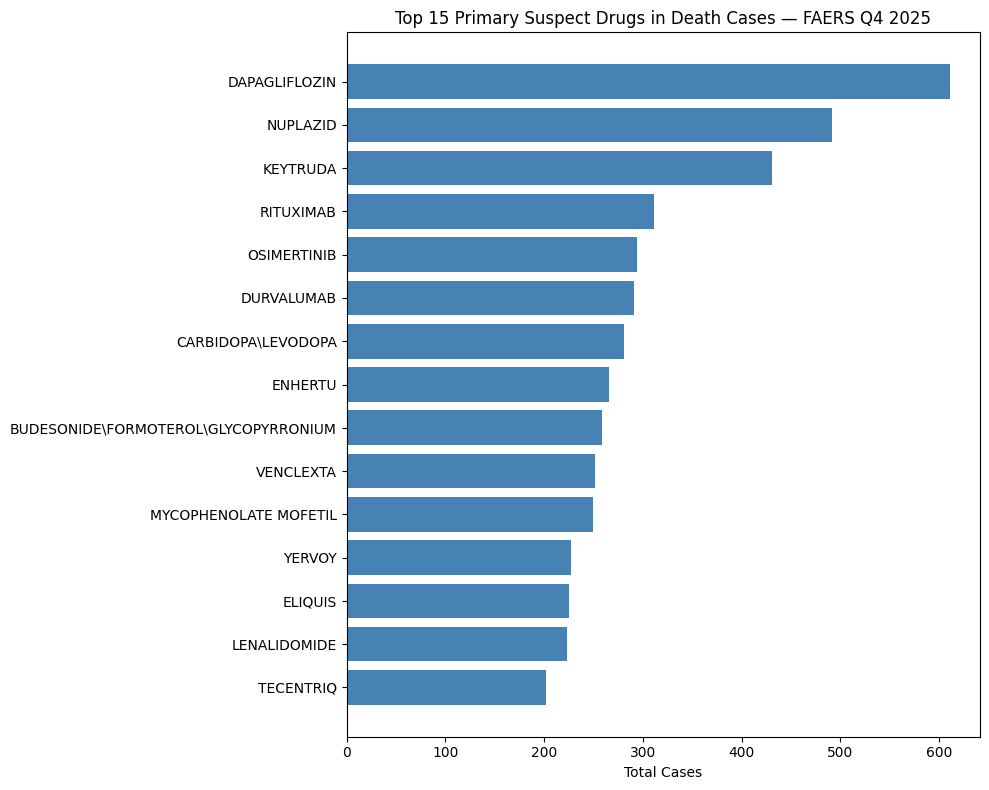

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(death_drugs['drugname'], death_drugs['total_cases'], color='steelblue')
plt.xlabel('Total Cases')
plt.title('Top 15 Primary Suspect Drugs in Death Cases — FAERS Q4 2025')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

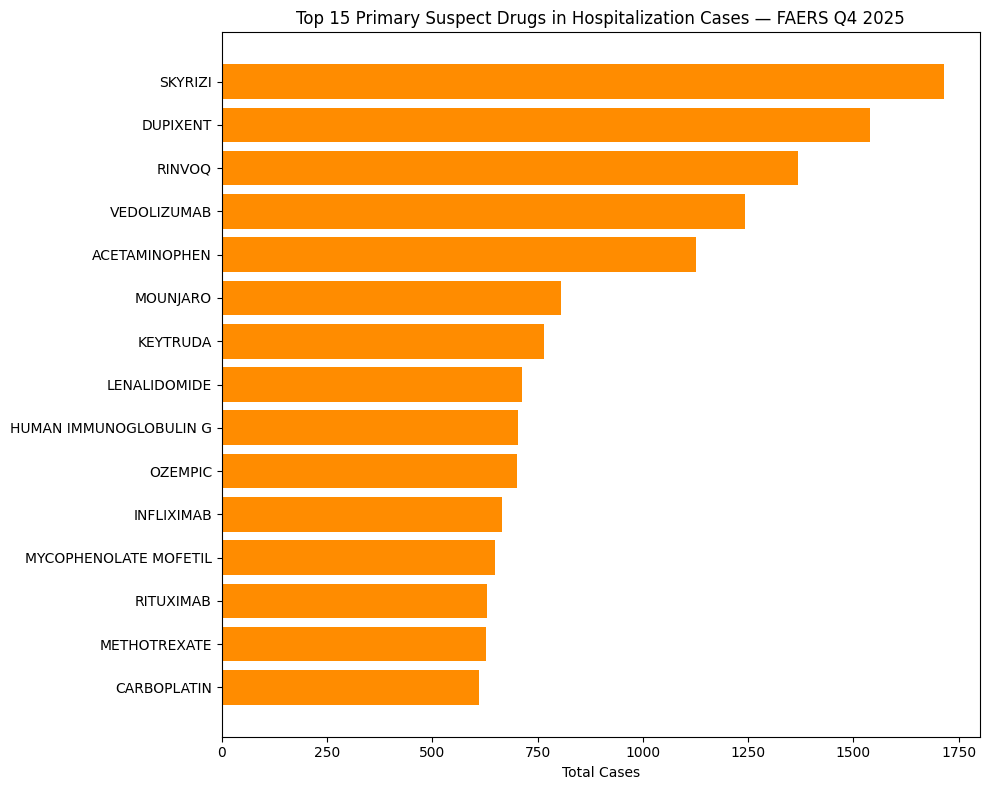

In [30]:
hosp_drugs = pd.read_sql("""
    SELECT DRUG25Q4.drugname, COUNT(DISTINCT DRUG25Q4.primaryid) AS total_cases
    FROM DRUG25Q4
    JOIN OUTC25Q4 ON DRUG25Q4.primaryid = OUTC25Q4.primaryid
    WHERE OUTC25Q4.outc_cod = 'HO' AND DRUG25Q4.role_cod = 'PS'
    GROUP BY DRUG25Q4.drugname
    ORDER BY total_cases DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(10, 8))
plt.barh(hosp_drugs['drugname'], hosp_drugs['total_cases'], color='darkorange')
plt.xlabel('Total Cases')
plt.title('Top 15 Primary Suspect Drugs in Hospitalization Cases — FAERS Q4 2025')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

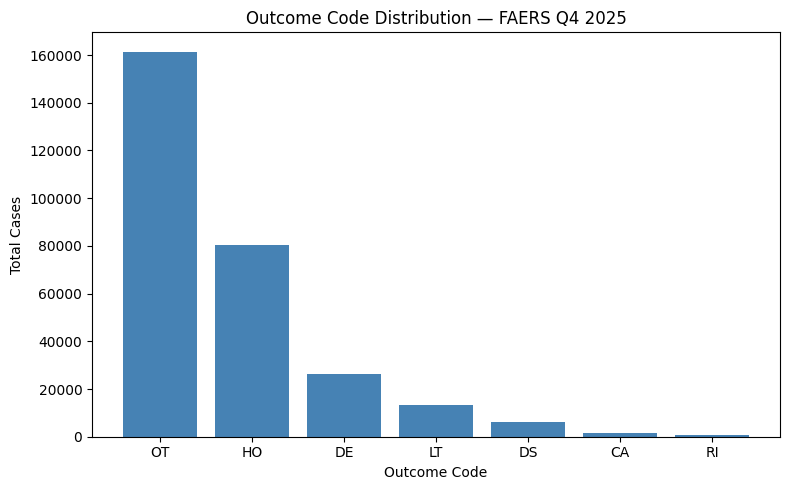

In [31]:
outcomes = pd.read_sql("""
    SELECT outc_cod, COUNT(DISTINCT primaryid) AS total_cases
    FROM OUTC25Q4
    GROUP BY outc_cod
    ORDER BY total_cases DESC
""", conn)

plt.figure(figsize=(8, 5))
plt.bar(outcomes['outc_cod'], outcomes['total_cases'], color='steelblue')
plt.xlabel('Outcome Code')
plt.ylabel('Total Cases')
plt.title('Outcome Code Distribution — FAERS Q4 2025')
plt.tight_layout()
plt.show()

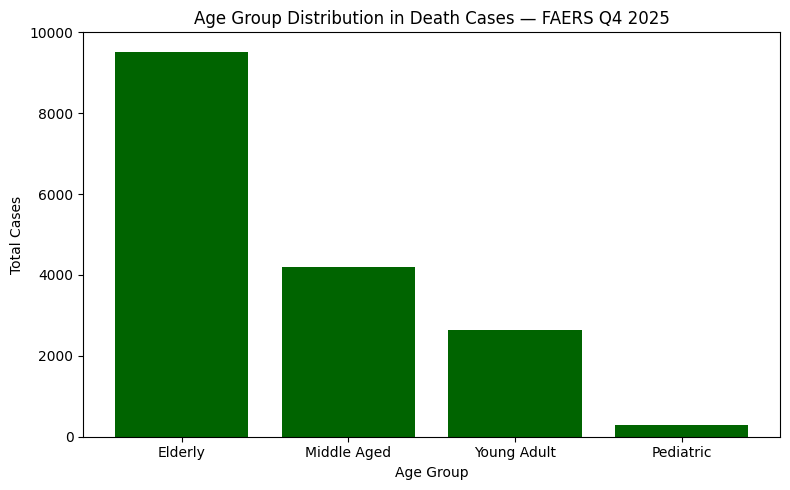

In [32]:
age_death = pd.read_sql("""
    SELECT 
        CASE 
            WHEN age < 18 THEN 'Pediatric'
            WHEN age < 45 THEN 'Young Adult'
            WHEN age < 65 THEN 'Middle Aged'
            ELSE 'Elderly'
        END AS age_group,
        COUNT(DISTINCT DEMO25Q4.primaryid) AS total_cases
    FROM DEMO25Q4
    JOIN OUTC25Q4 ON DEMO25Q4.primaryid = OUTC25Q4.primaryid
    WHERE age IS NOT NULL AND age_cod = 'YR' AND OUTC25Q4.outc_cod = 'DE'
    GROUP BY age_group
    ORDER BY total_cases DESC
""", conn)

plt.figure(figsize=(8, 5))
plt.bar(age_death['age_group'], age_death['total_cases'], color='darkgreen')
plt.xlabel('Age Group')
plt.ylabel('Total Cases')
plt.title('Age Group Distribution in Death Cases — FAERS Q4 2025')
plt.tight_layout()
plt.show()